### Experiemnt I


This experiment tests whether branch prediction actually affects real running time. The idea is to run the exact same data-dependent branch (a simple "if value >= threshold" check) over the exact same data, and change only one thing: how predictable the branch outcome is. I start with a sorted array, where the branch outcome comes in long predictable runs, and then progressively shuffle more of it so the outcome becomes more random. Since the data, the number of operations, and the memory use all stay the same, any change in runtime has to come from branch predictability alone. I run it in pure Python, where the branch is genuinely executed, and also with numba, where the compiler tends to turn the loop into branchless code and the effect disappears. To keep the timing reliable on a shared Colab CPU, I interleave the runs across all the shuffle levels and report the median so one noisy moment doesn't wreck a single configuration.

In [5]:
# =====================================================================
# EXPERIMENT 1: Branch Prediction
# Question we try to aswer here: does branch predictability affect real running time?
# Method: run the SAME data-dependent branch over the SAME data, changing
# ONLY how predictable the branch outcome is. We take a sorted array
# (branch outcome comes in long predictable runs) and progressively shuffle
# a fraction p of it (making the branch outcome more random). Since the data
# values, operation count, and memory footprint are identical, any change in
# runtime is attributable to branch predictability.
#
# Robust measurement: on shared cloud CPUs (Colab), a transient slowdown can
# corrupt an entire configuration if all its runs happen back-to-back. To
# guard against this, we INTERLEAVE. We cycle through every fraction, timing
# one run each per cycle, repeated for many cycles. A brief slowdown then hits
# all configurations roughly equally instead of ruining one. We report the
# MEDIAN per fraction (robust to the remaining outliers) plus the std.

import numpy as np
import time

try:
    from numba import njit
    HAVE_NUMBA = True
except ImportError:
    HAVE_NUMBA = False
    print("numba not found (run: !pip install numba). Skipping numba part.\n")


# ---------- the workload: one data-dependent branch per element ----------
def sum_above_py(lst, threshold):
    total = 0
    for v in lst:
        if v >= threshold:
            total += v
    return total


if HAVE_NUMBA:
    @njit(cache=True)
    def sum_above_nb(arr, threshold):
        total = 0
        for i in range(arr.shape[0]):
            if arr[i] >= threshold:
                total += arr[i]
        return total


def make_blend(base_sorted, p, rng):
    """Copy of a sorted array with fraction p of positions shuffled.
    p=0 -> fully predictable branch, p=1 -> fully unpredictable branch."""
    a = base_sorted.copy()
    k = int(p * a.shape[0])
    if k > 0:
        idx = rng.choice(a.shape[0], size=k, replace=False)
        vals = a[idx]
        rng.shuffle(vals)
        a[idx] = vals
    return a


def interleaved_bench(fn, inputs, threshold, cycles, warmup=3):
    """Time fn once per input per cycle, cycling through inputs each round.
    inputs: list of prepared arguments (one per fraction).
    Returns list of (median, std) per input. Interleaving spreads transient
    system noise across all inputs instead of concentrating it in one."""
    for x in inputs:
        for _ in range(warmup):
            fn(x, threshold)

    samples = [[] for _ in inputs]
    for _ in range(cycles):
        for i, x in enumerate(inputs):
            t0 = time.perf_counter()
            fn(x, threshold)
            t1 = time.perf_counter()
            samples[i].append(t1 - t0)

    out = []
    for s in samples:
        s = np.array(s)
        out.append((np.median(s), s.std()))
    return out


def main():
    N = 2_000_000
    threshold = 128
    fractions = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
    PY_CYCLES = 20
    NB_CYCLES = 50

    rng = np.random.default_rng(1)
    base_sorted = np.sort(rng.integers(0, 256, size=N))

    py_inputs = [make_blend(base_sorted, p, rng).tolist() for p in fractions]

    print(f"Array size: {N:,}   threshold: {threshold}")
    print(f"Pure Python: median +/- std over {PY_CYCLES} interleaved cycles.")
    print(f"numba:       median +/- std over {NB_CYCLES} interleaved cycles.")
    print("Lower is faster.\n")

    # ---------- (A) Pure Python ----------
    print("(A) Pure Python  [branch is genuinely executed]")
    print("    fraction shuffled  ->  median (s)  +/- std        (relative to sorted)")
    py_res = interleaved_bench(sum_above_py, py_inputs, threshold, PY_CYCLES)
    base_med = py_res[0][0]
    for p, (med, std) in zip(fractions, py_res):
        print(f"      {p:>5.2f}            ->  {med:.4f}    +/- {std:.4f}    ({med/base_med:.3f}x)")

    # ---------- (B) numba ----------
    if HAVE_NUMBA:
        nb_inputs = [make_blend(base_sorted, p, rng) for p in fractions]
        for _ in range(3):
            sum_above_nb(base_sorted, threshold)
        print("\n(B) numba JIT  [compiler may vectorize the branch away]")
        print("    fraction shuffled  ->  median (s)   +/- std          (relative to sorted)")
        nb_res = interleaved_bench(sum_above_nb, nb_inputs, threshold, NB_CYCLES)
        base_med_nb = nb_res[0][0]
        for p, (med, std) in zip(fractions, nb_res):
            print(f"      {p:>5.2f}            ->  {med:.6f}  +/- {std:.6f}  ({med/base_med_nb:.3f}x)")

    print("\nInterpretation hint:")
    print(" - If pure-Python median rises as 'fraction shuffled' increases, and")
    print("   the rise is large relative to the std, that reflects growing branch")
    print("   mispredictions (all else is equal).")
    print(" - If numba median stays flat, the compiler likely turned the loop into")
    print("   branchless/vectorized code, so there is no branch left to mispredict.")


main()

Array size: 2,000,000   threshold: 128
Pure Python: median +/- std over 20 interleaved cycles.
numba:       median +/- std over 50 interleaved cycles.
Lower is faster.

(A) Pure Python  [branch is genuinely executed]
    fraction shuffled  ->  median (s)  +/- std        (relative to sorted)
       0.00            ->  0.0582    +/- 0.0287    (1.000x)
       0.05            ->  0.0597    +/- 0.0257    (1.026x)
       0.10            ->  0.0611    +/- 0.0247    (1.050x)
       0.25            ->  0.0652    +/- 0.0261    (1.120x)
       0.50            ->  0.0740    +/- 0.0249    (1.271x)
       1.00            ->  0.0866    +/- 0.0205    (1.488x)

(B) numba JIT  [compiler may vectorize the branch away]
    fraction shuffled  ->  median (s)   +/- std          (relative to sorted)
       0.00            ->  0.001442  +/- 0.000129  (1.000x)
       0.05            ->  0.001442  +/- 0.000084  (1.000x)
       0.10            ->  0.001438  +/- 0.000061  (0.997x)
       0.25            ->  0.0014

***

## Experiment II

This experiment looks at whether exposing the independent work inside matrix-chain multiplication's inner loop actually speeds things up. The DP has an inner loop over the split point k, and the arithmetic for each k is independent since it only reads table entries that were already computed. That kind of independent work is what a CPU can overlap through instruction-level parallelism, but only if the code lets it. So I compare two versions that solve the exact same recurrence and have the same O(n^3) complexity: a scalar version with a plain Python loop over k, and a vectorized version that computes all the candidate costs at once as a NumPy array and takes the minimum. I first run a correctness check against the classic textbook example (which should give 15125) to confirm both versions agree, then time them across growing n. One honest caveat: the vectorized speedup mixes several effects together, like getting rid of Python interpreter overhead, SIMD, better cache use, and ILP, so I can't credit the gain to ILP alone without hardware counters. What's interesting is that the vectorized version is actually slower for small n and only pulls ahead once n gets big enough for the independent work to be worth it.

In [6]:
"""
Experiment 2: Independent inner-loop work (ILP / vectorization) in
matrix-chain multiplication.

The DP recurrence for matrix-chain multiplication is:

    m[i][j] = min over k in [i, j-1] of
                  m[i][k] + m[k+1][j] + p[i-1]*p[k]*p[j]

The inner loop over the split point k evaluates one candidate cost per k and
keeps the minimum. The arithmetic for different k values is INDEPENDENT (each
only reads already-computed table entries), which is exactly the kind of work
a CPU can overlap via instruction-level parallelism -- but only if the code
exposes it. We compare:

  (A) scalar: an explicit Python loop over k with a running-min 'if'.
  (B) vectorized: compute all candidate costs for k at once as a NumPy array
      and take np.min. NumPy runs this in compiled code, exposing the
      independent work to the hardware (SIMD + ILP + no interpreter overhead).

Both have identical O(n^3) complexity and must return the same answer.

NOTE (we have mentioned this is the discussion section of our report): the vectorized speedup bundles several effects together --
elimination of Python interpreter overhead (usually dominant), SIMD/data
parallelism, better cache use, and ILP proper. We cannot cleanly isolate ILP
alone without hardware counters, so we interpret this as the practical payoff
of exposing independent work to compiled execution, of which ILP is one part.
"""


def matrix_chain_scalar(p):
    """p: list of dimensions, length n+1, for n matrices. Returns min cost."""
    n = len(p) - 1
    m = [[0] * (n + 1) for _ in range(n + 1)]
    for length in range(2, n + 1):                 # chain length
        for i in range(1, n - length + 2):         # start index
            j = i + length - 1
            best = float("inf")
            for k in range(i, j):                  # split point (independent work)
                cost = m[i][k] + m[k + 1][j] + p[i - 1] * p[k] * p[j]
                if cost < best:                    # data-dependent running min
                    best = cost
            m[i][j] = best
    return m[1][n]


def matrix_chain_vectorized(p):
    """Same recurrence, but the inner loop over k is done as vector operations."""
    n = len(p) - 1
    p = np.asarray(p, dtype=np.int64)
    m = np.zeros((n + 1, n + 1), dtype=np.float64)
    for length in range(2, n + 1):
        for i in range(1, n - length + 2):
            j = i + length - 1
            ks = np.arange(i, j)                    # all split points at once
            # all candidate costs computed together/independent arithmetic
            costs = m[i, ks] + m[ks + 1, j] + p[i - 1] * p[ks] * p[j]
            m[i, j] = costs.min()
    return m[1, n]


def timed_stats(fn, arg, repeats=10, warmup=2):
    for _ in range(warmup):
        fn(arg)
    s = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(arg)
        t1 = time.perf_counter()
        s.append(t1 - t0)
    s = np.array(s)
    return np.median(s), s.std()


def main():
    rng = np.random.default_rng(0)

    # ---- This is just correctness check on a small instance to make sure all is good ----
    p_small = [30, 35, 15, 5, 10, 20, 25]
    a = matrix_chain_scalar(p_small)
    b = matrix_chain_vectorized(p_small)
    print(f"Correctness check (CLRS example): scalar={a}, vectorized={b}, "
          f"match={a == b}")
    print("(expected optimal cost = 15125)\n")

    # ---- timing across increasing n ----

    plan = [(50, 15), (100, 15), (150, 10), (200, 10),
            (300, 7), (400, 5), (450, 5)]
    print("Matrix-chain DP: scalar vs vectorized (median of R runs)\n")
    print("   n    R    scalar (s)     vectorized (s)   speedup")
    for n, R in plan:
        p = rng.integers(1, 100, size=n + 1).tolist()
        sc_med, _ = timed_stats(matrix_chain_scalar, p, repeats=R)
        ve_med, _ = timed_stats(matrix_chain_vectorized, p, repeats=R)
        print(f"  {n:>3}   {R:>2}   {sc_med:8.4f}       {ve_med:8.4f}        "
              f"{sc_med / ve_med:6.2f}x")


main()

Correctness check (CLRS example): scalar=15125, vectorized=15125.0, match=True
(expected optimal cost = 15125)

Matrix-chain DP: scalar vs vectorized (median of R runs)

   n    R    scalar (s)     vectorized (s)   speedup
   50   15     0.0083         0.0197          0.42x
  100   15     0.0320         0.0816          0.39x
  150   10     0.1076         0.1871          0.58x
  200   10     0.3633         0.3602          1.01x
  300    7     1.3046         0.8179          1.60x
  400    5     2.4422         1.5294          1.60x
  450    5     3.5264         1.9456          1.81x


***

### Data Visualization


saved fig_branch_prediction.png
saved fig_matrix_chain.png


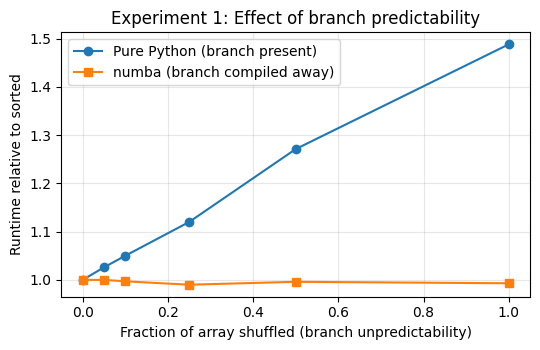

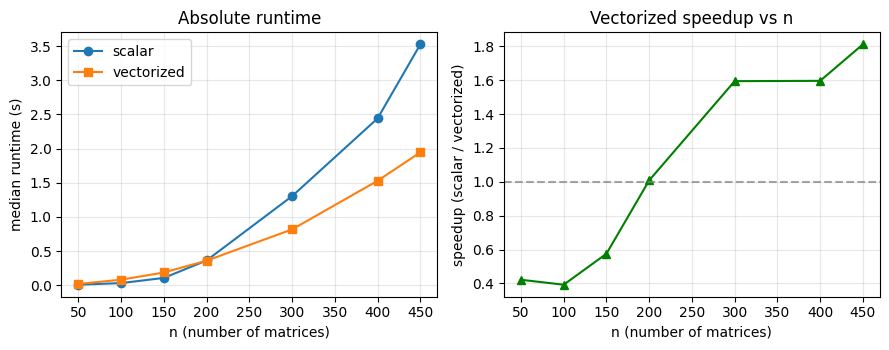

In [9]:
"""
Plots for the report. Paste YOUR measured numbers into the marked arrays,
then run. Saves two PNG files to insert into the LaTeX document.
In Colab the files appear in the file browser (left panel) for download.
"""

import matplotlib.pyplot as plt

# ============================================================
# FIGURE 1: Branch prediction sweep (Experiment 1)
# >>> PASTE YOUR EXPERIMENT 1 "relative to sorted" NUMBERS HERE <
# ============================================================
frac_shuffled = [0.00, 0.05, 0.10, 0.25, 0.50, 1.00]
py_relative   = [1.000, 1.026, 1.050, 1.120, 1.271, 1.488]   # pure Python column
nb_relative   = [1.000, 1.000, 0.997, 0.990, 0.996, 0.993]   # numba column

plt.figure(figsize=(5.5, 3.6))
plt.plot(frac_shuffled, py_relative, marker="o", label="Pure Python (branch present)")
plt.plot(frac_shuffled, nb_relative, marker="s", label="numba (branch compiled away)")
plt.xlabel("Fraction of array shuffled (branch unpredictability)")
plt.ylabel("Runtime relative to sorted")
plt.title("Experiment 1: Effect of branch predictability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("fig_branch_prediction.png", dpi=150)
print("saved fig_branch_prediction.png")

# ============================================================
# FIGURE 2: Matrix-chain scalar vs vectorized (Experiment 2)
# >>> PASTE YOUR EXPERIMENT 2 NUMBERS HERE <
# ============================================================
n_values = [50, 100, 150, 200, 300, 400, 450]
scalar_t = [0.0083, 0.0320, 0.1076, 0.3633, 1.3046, 2.4422, 3.5264]   # scalar (s) column
vector_t = [0.0197, 0.0816, 0.1871, 0.3602, 0.8179, 1.5294, 1.9456]   # vectorized (s) column

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))

ax1.plot(n_values, scalar_t, marker="o", label="scalar")
ax1.plot(n_values, vector_t, marker="s", label="vectorized")
ax1.set_xlabel("n (number of matrices)")
ax1.set_ylabel("median runtime (s)")
ax1.set_title("Absolute runtime")
ax1.grid(True, alpha=0.3)
ax1.legend()

speedup = [s / v for s, v in zip(scalar_t, vector_t)]
ax2.plot(n_values, speedup, marker="^", color="green")
ax2.axhline(1.0, linestyle="--", color="gray", alpha=0.7)
ax2.set_xlabel("n (number of matrices)")
ax2.set_ylabel("speedup (scalar / vectorized)")
ax2.set_title("Vectorized speedup vs n")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_matrix_chain.png", dpi=150)
print("saved fig_matrix_chain.png")

✌